In [53]:
#https://www.kaggle.com/datasets/dhruvildave/wikibooks-dataset?resource=download

import kagglehub
import os
!pip install keras
import sqlite3
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import random
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Dropout
from sklearn.model_selection import train_test_split

In [54]:
path = kagglehub.dataset_download("dhruvildave/wikibooks-dataset")

print("Path to dataset files:", path)
print(os.listdir(path))

Path to dataset files: /kaggle/input/wikibooks-dataset
['wikibooks.sqlite']


In [55]:
conn = sqlite3.connect(f'{path}/wikibooks.sqlite')

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)

   name
0    pl
1    hu
2    he
3    nl
4    ja
5    ru
6    it
7    en
8    es
9    pt
10   de
11   fr


In [56]:
df = pd.read_sql("SELECT * FROM ru;", conn)
print(df)

                                                  title  \
0     Викиучебник: Техника и технология средств масс...   
1              Викиучебник: АОН/Пилотское свидетельство   
2     Викиучебник: Книга программиста/Структуры данн...   
3     Викиучебник: Тесты НМО/Гигиенические основы и ...   
4                      Викиучебник: Коктейли/Пенная фея   
...                                                 ...   
8208                    Викиучебник: Коктейли/Чики-пуки   
8209                 Викиучебник: Коктейли/Будьте добры   
8210             Викиучебник: Коктейли/Античный дайкири   
8211  Викиучебник: Открытый учебник нейронаук/Патоло...   
8212  Викиучебник: Тесты НМО/Аллергический конъюнктивит   

                                                    url  \
0     https://ru.wikibooks.org/wiki/%D0%A2%D0%B5%D1%...   
1     https://ru.wikibooks.org/wiki/%D0%90%D0%9E%D0%...   
2     https://ru.wikibooks.org/wiki/%D0%9A%D0%BD%D0%...   
3     https://ru.wikibooks.org/wiki/%D0%A2%D0%B5%D1%...

In [57]:
text = " ".join((df['abstract'].fillna('') + " " + df['body_text'].fillna('')).tolist())
#text = " ".join((df['abstract'].fillna('')).tolist())
text = text[:100000]
print(text[:1000])

* [станция|Рабочая станция]; Рабочая станция;
Сервер;
Персональный компьютер. Гражданское пилотское свидетельство - разрешение на управление определенным видом воздушного судна. Внутри этого свидетельства может быть много разных отметок (а может и не быть), которые или урезают или увеличивают количество разрешенных функций. В Википедии имеется статья по теме «Свидетельство частного пилота»


Гражданское пилотское свидетельство - разрешение на управление определенным видом воздушного судна. Внутри этого свидетельства может быть много разных отметок (а может и не быть), которые или урезают или увеличивают количество разрешенных функций. Самое понятное и известное массам это свидетельство частного пилота. Его выдают после обучения на самолете или на вертолете. Для краткости в разговорной речи это свидетельство могут обозначать через название его иностранного аналога - ППЛ или ПиПиЭль (PPL).  Раньше это свидетельство в России называлось свидетельство пилота-любителя.
Порядок выдачи свидете

In [58]:
#Посимвольно
tokenizer_char = Tokenizer(char_level=True)
tokenizer_char.fit_on_texts([text])
print(tokenizer_char.word_index)

{' ': 1, 'e': 2, '\n': 3, 't': 4, 'r': 5, 'n': 6, 'о': 7, 'е': 8, 'и': 9, 'o': 10, 'а': 11, 'i': 12, 'a': 13, 'н': 14, 'т': 15, 'с': 16, 'c': 17, 'l': 18, 's': 19, ';': 20, 'в': 21, 'р': 22, 'd': 23, '(': 24, ')': 25, ':': 26, 'u': 27, 'л': 28, 'к': 29, 'p': 30, 'п': 31, 'д': 32, 'м': 33, '=': 34, '.': 35, 'f': 36, 'у': 37, 'g': 38, '_': 39, ',': 40, 'v': 41, 'b': 42, 'я': 43, 'm': 44, 'ы': 45, 'ь': 46, 'y': 47, 'з': 48, 'г': 49, '1': 50, 'x': 51, 'ч': 52, 'й': 53, 'w': 54, '/': 55, '2': 56, 'б': 57, 'ц': 58, '0': 59, 'h': 60, '-': 61, '[': 62, ']': 63, 'ж': 64, 'х': 65, 'ю': 66, 'ф': 67, "'": 68, 'ш': 69, 'щ': 70, 'z': 71, 'k': 72, 'э': 73, '3': 74, 'j': 75, '–': 76, '*': 77, '<': 78, '5': 79, '+': 80, 'q': 81, '>': 82, '{': 83, '}': 84, '6': 85, '4': 86, '?': 87, '"': 88, '8': 89, '«': 90, '»': 91, '·': 92, '7': 93, '\t': 94, '\xa0': 95, '9': 96, 'ё': 97, 'ъ': 98, '^': 99, '—': 100, '%': 101, '&': 102, '|': 103, '↑': 104}


In [59]:
#По словам
tokenizer_word = Tokenizer(num_words=5000)
tokenizer_word.fit_on_texts([text])
print(tokenizer_word.word_index)

{'end': 1, 'begin': 2, 'function': 3, 'i': 4, 'result': 5, 'a': 6, '0': 7, 'var': 8, 'procedure': 9, 'class': 10, 'self': 11, 'v': 12, 'x': 13, 'integer': 14, 'b': 15, 'y': 16, 'в': 17, '1': 18, '–': 19, 'new': 20, 'count': 21, 'править': 22, 'do': 23, "'": 24, 'r': 25, 'real': 26, 'operator': 27, '2': 28, 'l': 29, 'pred': 30, 'for': 31, 'и': 32, 'j': 33, 'to': 34, 'tdynamicarray': 35, 'write': 36, 'if': 37, 'then': 38, 'property': 39, 'read': 40, 'k': 41, 'tmatrix': 42, 'n': 43, 'tfraction': 44, 'c1': 45, 'c': 46, 'на': 47, 'v1': 48, 'z': 49, 'cloneas': 50, 'возвращает': 51, 'tostring': 52, 'println': 53, 'к': 54, 'f1': 55, 'extensionmethod': 56, 'rowscount': 57, 'colscount': 58, 'tvector2d': 59, 'с': 60, 'g': 61, '3': 62, 'next': 63, 'tvector3d': 64, '5': 65, 'tpoint': 66, 'f': 67, 'numerator': 68, 'denominator': 69, 'tcolor': 70, 'это': 71, 'and': 72, 'из': 73, 'f2': 74, 'type': 75, 'boolean': 76, 'nil': 77, 'eps': 78, 'trange': 79, 'print': 80, 'tlinkedlist': 81, 'clone': 82, 'свид

In [60]:
char_to_index = tokenizer_char.word_index
index_to_char = {i: c for c, i in char_to_index.items()}
vocab_size = len(char_to_index) + 1  # +1 для паддинга
sequences_char = tokenizer_char.texts_to_sequences([text])[0] #преобразование текста в индексы на основе посимвольного токенайзера
#print(sequences_char)

In [61]:
def simple_generator(X_data, y_data, batch_size, vocab_size):
    while True:
        for i in range(0, len(X_data), batch_size):
            X_batch = X_data[i:i+batch_size]
            y_batch = y_data[i:i+batch_size]
            X = np.array([to_categorical(seq, num_classes=vocab_size) for seq in X_batch])
            y = to_categorical(y_batch, num_classes=vocab_size)
            yield X, y

In [62]:
seq_length = 15
X, y = [], []

for i in range(len(sequences_char) - seq_length):
    X.append(sequences_char[i:i+seq_length])
    y.append(sequences_char[i+seq_length])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1249/1249 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.2903 - loss: 2.9210 - val_accuracy: 0.5180 - val_loss: 1.8444
Epoch 2/50
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5369 - loss: 1.7648 - val_accuracy: 0.5707 - val_loss: 1.5833
Epoch 3/50
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5936 - loss: 1.5140 - val_accuracy: 0.6030 - val_loss: 1.4691
Epoch 4/50
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6294 - loss: 1.3726 - val_accuracy: 0.6221 - val_loss: 1.4012
Epoch 5/50
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.6508 - loss: 1.2814 - val_accuracy: 0.6323 - val_loss: 1.3588
Epoch 6/50
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6661 - loss: 1.2126 - val_accuracy: 0.6421 - val_loss: 1.3321
Epoch 7/50
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6828 - loss: 1.1527 - val_accuracy: 0.6438 - val_loss: 1.3148
Epoch 8/50
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6901 - loss: 1.1147 - val_accu

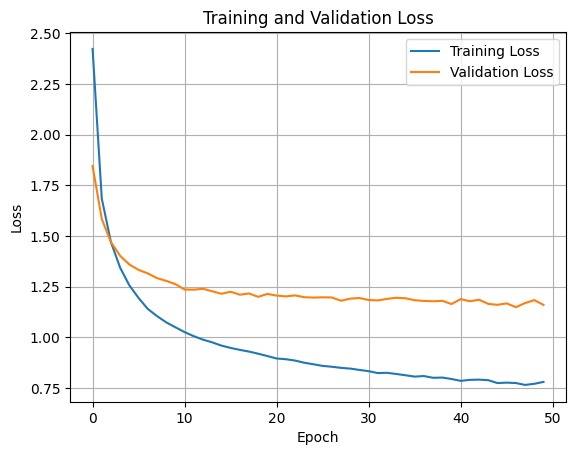

In [63]:
model_char = Sequential()
model_char.add(SimpleRNN(256, return_sequences=True, input_shape=(seq_length, vocab_size)))
model_char.add(SimpleRNN(128))
model_char.add(Dense(vocab_size, activation='softmax'))

model_char.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

batch_size = 64
train_gen = simple_generator(X_train, y_train, batch_size, vocab_size)
val_gen = simple_generator(X_test, y_test, batch_size, vocab_size)

steps_per_epoch = len(X_train) // batch_size
validation_steps = len(X_test) // batch_size

history = model_char.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=50
)

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [64]:
word_to_index = tokenizer_word.word_index
index_to_word = {i: c for c, i in word_to_index.items()}
vocab_size = len(word_to_index) + 1  # +1 для паддинга
sequences_word = tokenizer_word.texts_to_sequences([text])[0] #преобразование текста в индексы на основе посимвольного токенайзера
print(sequences_word)

[487, 631, 487, 631, 487, 1127, 1128, 1129, 488, 148, 83, 489, 47, 632, 633, 634, 374, 375, 179, 376, 108, 142, 165, 635, 377, 490, 243, 142, 32, 92, 165, 180, 115, 636, 115, 637, 378, 638, 639, 17, 1130, 1131, 1132, 101, 1133, 1134, 379, 1135, 488, 148, 83, 489, 47, 632, 633, 634, 374, 375, 179, 376, 108, 142, 165, 635, 377, 490, 243, 142, 32, 92, 165, 180, 115, 636, 115, 637, 378, 638, 639, 1136, 1137, 32, 1138, 1139, 71, 83, 379, 149, 143, 640, 215, 380, 47, 491, 115, 47, 1140, 116, 1141, 17, 1142, 1143, 71, 83, 492, 1144, 216, 244, 143, 641, 1145, 1146, 115, 1147, 642, 493, 71, 83, 17, 150, 1148, 83, 149, 1149, 643, 1150, 274, 644, 17, 494, 645, 646, 376, 495, 496, 1151, 1152, 1153, 18, 1154, 274, 1155, 1156, 54, 1157, 1158, 144, 1159, 381, 319, 108, 497, 17, 647, 498, 32, 71, 648, 1160, 245, 17, 649, 1161, 203, 1162, 1163, 382, 1164, 17, 377, 499, 1165, 1166, 650, 101, 1167, 17, 150, 500, 650, 320, 115, 1168, 92, 651, 17, 1169, 1170, 321, 1171, 1172, 652, 501, 1173, 1174, 1175, 83

In [65]:
seq_length = 10
X, y = [], []

for i in range(len(sequences_word) - seq_length):
    X.append(sequences_word[i:i+seq_length])
    y.append(sequences_word[i+seq_length])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - accuracy: 0.0086 - loss: 7.3363 - val_accuracy: 0.0195 - val_loss: 6.4505
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.0227 - loss: 6.3595 - val_accuracy: 0.0269 - val_loss: 6.4702
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - accuracy: 0.0233 - loss: 6.3258 - val_accuracy: 0.0256 - val_loss: 6.5189
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 145ms/step - accuracy: 0.0219 - loss: 6.3030 - val_accuracy: 0.0249 - val_loss: 6.5360
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - accuracy: 0.0262 - loss: 6.1392 - val_accuracy: 0.0365 - val_loss: 6.1947
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.0321 - loss: 5.9251 - val_accuracy: 0.0379 - val_loss: 6.2021
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 137ms/step - accuracy: 0.0359 - loss: 5.7780 - val_accuracy: 0.0358 - val_loss: 6.1860
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 0.0400 - loss: 5.7042 - val_accuracy: 0.04

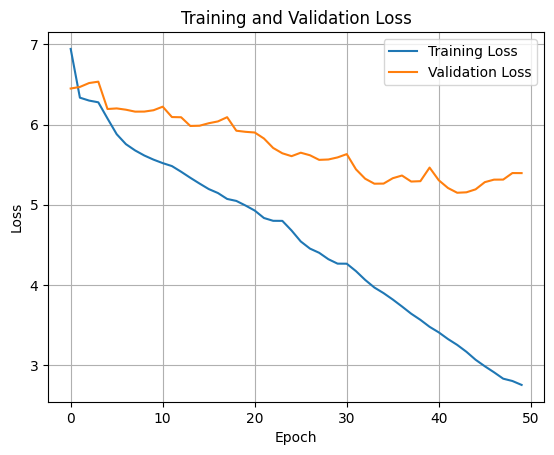

In [66]:
model_word = Sequential()
model_word.add(SimpleRNN(128, return_sequences=False, input_shape=(seq_length, vocab_size)))
model_word.add(Dropout(0.2))
#model_word.add(Embedding(input_dim=vocab_size, output_dim=64, input_length=seq_length))
#model_word.add(SimpleRNN(128))
#model_word.add(Dropout(0.2))
model_word.add(Dense(vocab_size, activation='softmax'))


model_word.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

batch_size = 256
train_gen = simple_generator(X_train, y_train, batch_size, vocab_size)
val_gen = simple_generator(X_test, y_test, batch_size, vocab_size)

steps_per_epoch = len(X_train) // batch_size
validation_steps = len(X_test) // batch_size

history = model_word.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=50
)

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [67]:
def generate_text(model, tokenizer, start, seq_length, vocab_size, index_to_token, char_level=True, length=50):
    result = start.strip()
    sequence = tokenizer.texts_to_sequences([result])[0]

    for _ in range(length):
        input_seq = sequence[-seq_length:]
        if len(input_seq) < seq_length:
            input_seq = [0] * (seq_length - len(input_seq)) + input_seq

        X = np.array([to_categorical(input_seq, num_classes=vocab_size)])

        pred = model.predict(X, verbose=0)[0]
        if pred.ndim == 2:
            pred = pred[-1]

        next_idx = np.argmax(pred)
        next_token = index_to_token.get(next_idx, '?')

        if char_level:
            result += next_token
            sequence.append(next_idx)
        else:
            result += ' ' + next_token
            sequence.append(next_idx)

    return result


print("Модель CHAR:")
print(generate_text(
    model=model_char,
    tokenizer=tokenizer_char,
    start="Всего у нас было 4 рыбы",
    seq_length=15,
    vocab_size=len(tokenizer_char.word_index) + 1,
    index_to_token={i: w for w, i in tokenizer_char.word_index.items()},
    char_level=True
))


print("Модель WORD:")
print(generate_text(
    model=model_word,
    tokenizer=tokenizer_word,
    start="Всего у нас было 4 рыбы",
    seq_length=10,
    vocab_size=len(tokenizer_word.word_index) + 1,
    index_to_token={i: w for w, i in tokenizer_word.word_index.items()},
    char_level=False
))

Модель CHAR:
Всего у нас было 4 рыбывает и боктать одного основной части уболи на базо
Модель WORD:
Всего у нас было 4 рыбы в в в и и свидетельство функцию двигательного паспорт россии ауц ауц ауц ауц ауц отметка следующими льда после не их которые которые в стандарте стандарте на свидетельство править править – свидетельство пилота ппп воздушного документа и не и и не название льда не пилота в ауц отметка ауц и
